Configuración e Importaciones
Asegúrate de que las librerías estén instaladas:
!pip install pandas matplotlib seaborn sqlite3

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

# Configuración de rutas
DB_FILE = 'db/videogames.db'
TABLE_NAME = 'vgsales_clean'
GRAPHICS_DIR = 'docs/EA2/graficos'

# Configuración de estilo de Matplotlib y Seaborn
plt.style.use('ggplot')
sns.set_theme(style="whitegrid")

def connect_db():
    """Establece la conexión a la base de datos SQLite."""
    try:
        conn = sqlite3.connect(DB_FILE)
        return conn
    except sqlite3.Error as e:
        print(f"Error al conectar a la base de datos {DB_FILE}: {e}")
        return None

def setup_graphics_dir():
    """Crea el directorio para guardar los gráficos si no existe."""
    os.makedirs(GRAPHICS_DIR, exist_ok=True)
    print(f"\nDirectorio de gráficos '{GRAPHICS_DIR}' verificado/creado.")
    
# Inicializar conexión y directorio
setup_graphics_dir()
conn = connect_db()

if conn:
    print("Conexión a SQLite exitosa. Continuar con el análisis...")
else:
    print("No se pudo establecer la conexión a la base de datos. Deteniendo el análisis.")


Directorio de gráficos 'docs/EA2/graficos' verificado/creado.
Conexión a SQLite exitosa. Continuar con el análisis...


Ventas por Género y Región

In [5]:
def analyze_sales_by_genre_and_region(conn):
    """
    Analizar qué género se vendió más y menos en cada continente.
    5 gráficos: 1 apilado global y 4 específicos por región.
    """
    print("\n" + "="*80)
    print("VENTAS TOTALES POR GÉNERO Y DISTRIBUCIÓN REGIONAL")
    print("="*80)
    
    query = f"""
    SELECT genre, 
           SUM(na_sales) AS NA_Sales, 
           SUM(eu_sales) AS EU_Sales, 
           SUM(jp_sales) AS JP_Sales, 
           SUM(other_sales) AS Other_Sales,
           SUM(global_sales) AS Global_Sales
    FROM {TABLE_NAME}
    GROUP BY genre
    ORDER BY Global_Sales DESC
    """
    df_sales = pd.read_sql_query(query, conn)
    
    df_regions = df_sales.set_index('genre')[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales']]
    region_totals = df_regions.sum().round(2)

    # 1. GRÁFICO APILADO GLOBAL (Para contexto general)
    plt.figure(figsize=(12, 8))
    df_regions.plot(kind='bar', stacked=True, colormap='viridis', ax=plt.gca())
    
    new_labels = [
        f"NA_Sales ({region_totals['NA_Sales']:.2f}M)",
        f"EU_Sales ({region_totals['EU_Sales']:.2f}M)",
        f"JP_Sales ({region_totals['JP_Sales']:.2f}M)",
        f"Other_Sales ({region_totals['Other_Sales']:.2f}M)"
    ]
    plt.title('1.1 Ventas Totales de Videojuegos por Género y Región (Global)', fontsize=16)
    plt.ylabel('Ventas Totales (en Millones)', fontsize=12)
    plt.xlabel('Género', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(labels=new_labels, title='Región (Total en Millones)')
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPHICS_DIR, 'q1_1_ventas_genero_region_global.png'))
    plt.show()
    
    print("\nINTERPRETACIÓN DEL GRÁFICO 1.1 (Global y Apilado):")
    print("• Ventas Regionales Totales: Norteamérica (NA) es, por amplio margen, el mercado más grande, seguido por Europa (EU). Japón (JP) es el tercer mercado, con ventas más enfocadas en ciertos géneros.")
    print("• Distribución Global: Los géneros Action y Sports son los pilares del mercado global, impulsados principalmente por las ventas occidentales (NA y EU).")
    print("-" * 80)


    # 2. GRÁFICOS INDIVIDUALES POR REGIÓN (Para detalle de género)
    regions = {'NA_Sales': 'Norteamérica', 'EU_Sales': 'Europa', 'JP_Sales': 'Japón', 'Other_Sales': 'Otras Regiones'}
    
    for col_name, region_name in regions.items():
        # Ordenar los géneros por ventas en esa región
        df_region_sorted = df_sales[['genre', col_name]].sort_values(by=col_name, ascending=False)
        
        plt.figure(figsize=(10, 6))
        sns.barplot(data=df_region_sorted, x='genre', y=col_name, palette='plasma')
        
        plt.title(f'1.2 Ventas de Videojuegos por Género en {region_name} (Total: {region_totals[col_name]:.2f}M)', fontsize=14)
        plt.ylabel('Ventas (en Millones)', fontsize=12)
        plt.xlabel('Género', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig(os.path.join(GRAPHICS_DIR, f'q1_2_ventas_genero_{col_name.lower()}.png'))
        plt.show()

        # Interpretación específica por región
        top_genre = df_region_sorted.iloc[0]['genre'].capitalize()
        bottom_genre = df_region_sorted.iloc[-1]['genre'].capitalize()
        
        print(f"\nINTERPRETACIÓN DEL GRÁFICO 1.2 ({region_name}):")
        if col_name == 'JP_Sales':
            print(f"• Dominio: El género {top_genre} es el más vendido en {region_name}, lo que subraya la fuerte preferencia japonesa por los juegos de rol. El segundo lugar (Platform) también es notablemente alto.")
        elif col_name in ['NA_Sales', 'EU_Sales']:
            print(f"• Dominio: El género {top_genre} lidera, seguido de cerca por Sports/Shooter, reflejando el gusto occidental por la acción y los deportes masivos.")
        else:
            print(f"• Dominio: {top_genre} también domina en {region_name}. Este mercado muestra tendencias similares a NA/EU en términos de géneros principales.")
        print(f"• Menos vendido: {bottom_genre} es consistentemente uno de los géneros con menores ventas en {region_name}.")
        print("-" * 80)
        
    print("\nAnálisis de la distribución de ventas por género en regiones completado. Se generaron 5 gráficos.")


VENTAS TOTALES POR GÉNERO Y DISTRIBUCIÓN REGIONAL


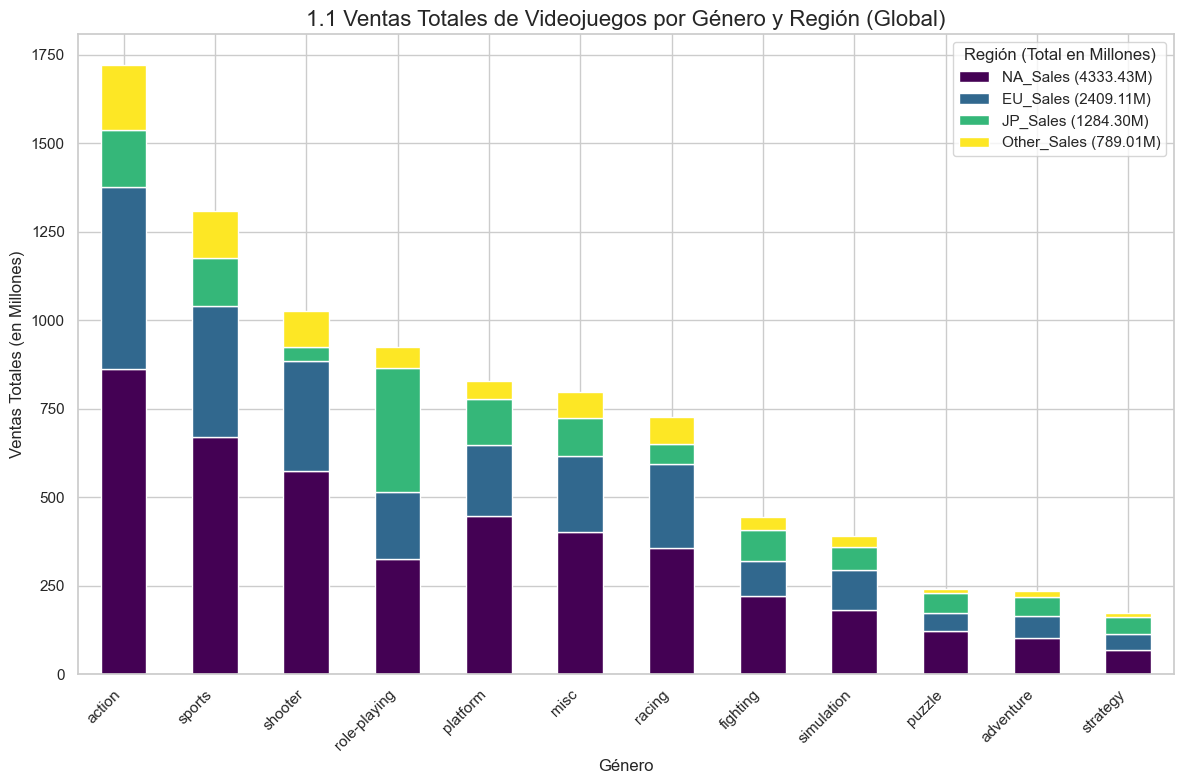


INTERPRETACIÓN DEL GRÁFICO 1.1 (Global y Apilado):
• Ventas Regionales Totales: Norteamérica (NA) es, por amplio margen, el mercado más grande, seguido por Europa (EU). Japón (JP) es el tercer mercado, con ventas más enfocadas en ciertos géneros.
• Distribución Global: Los géneros Action y Sports son los pilares del mercado global, impulsados principalmente por las ventas occidentales (NA y EU).
--------------------------------------------------------------------------------


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9316\3792058899.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_region_sorted, x='genre', y=col_name, palette='plasma')


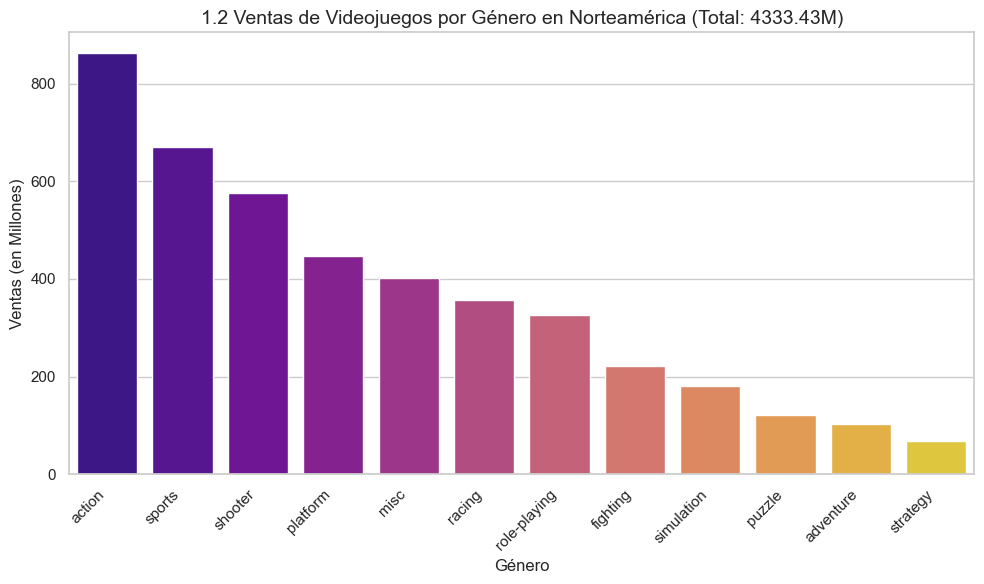


INTERPRETACIÓN DEL GRÁFICO 1.2 (Norteamérica):
• Dominio: El género Action lidera, seguido de cerca por Sports/Shooter, reflejando el gusto occidental por la acción y los deportes masivos.
• Menos vendido: Strategy es consistentemente uno de los géneros con menores ventas en Norteamérica.
--------------------------------------------------------------------------------


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9316\3792058899.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_region_sorted, x='genre', y=col_name, palette='plasma')


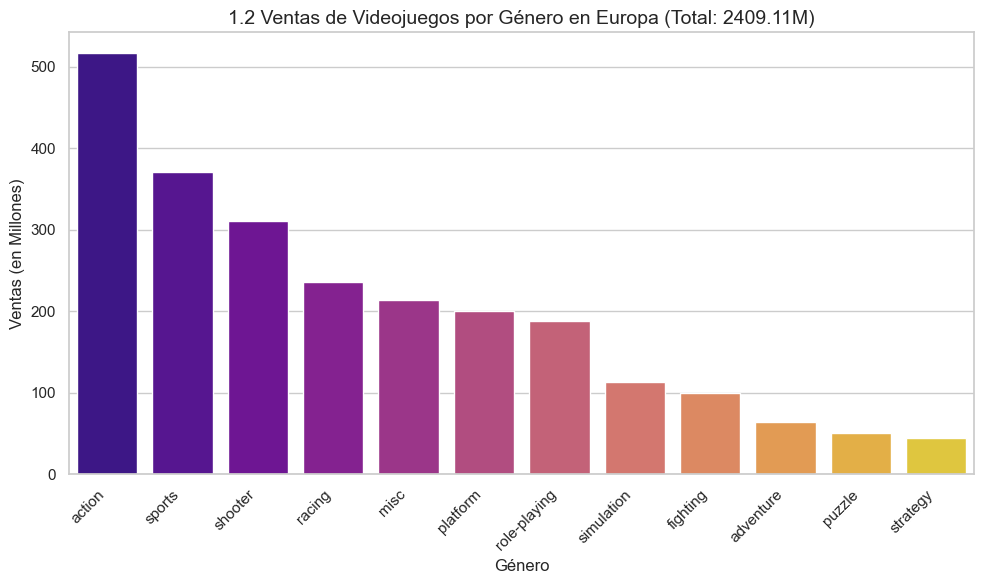


INTERPRETACIÓN DEL GRÁFICO 1.2 (Europa):
• Dominio: El género Action lidera, seguido de cerca por Sports/Shooter, reflejando el gusto occidental por la acción y los deportes masivos.
• Menos vendido: Strategy es consistentemente uno de los géneros con menores ventas en Europa.
--------------------------------------------------------------------------------


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9316\3792058899.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_region_sorted, x='genre', y=col_name, palette='plasma')


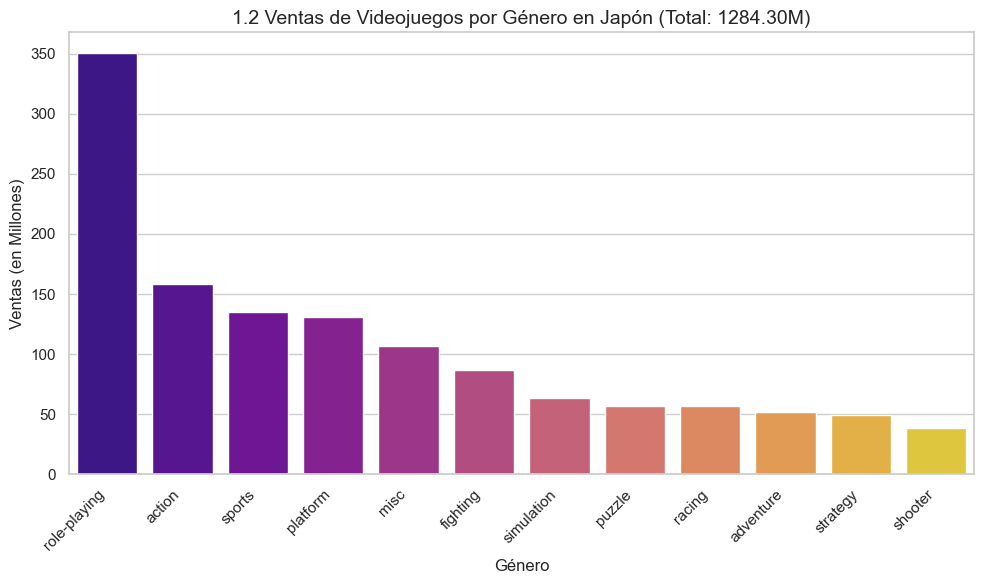


INTERPRETACIÓN DEL GRÁFICO 1.2 (Japón):
• Dominio: El género Role-playing es el más vendido en Japón, lo que subraya la fuerte preferencia japonesa por los juegos de rol. El segundo lugar (Platform) también es notablemente alto.
• Menos vendido: Shooter es consistentemente uno de los géneros con menores ventas en Japón.
--------------------------------------------------------------------------------


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9316\3792058899.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_region_sorted, x='genre', y=col_name, palette='plasma')


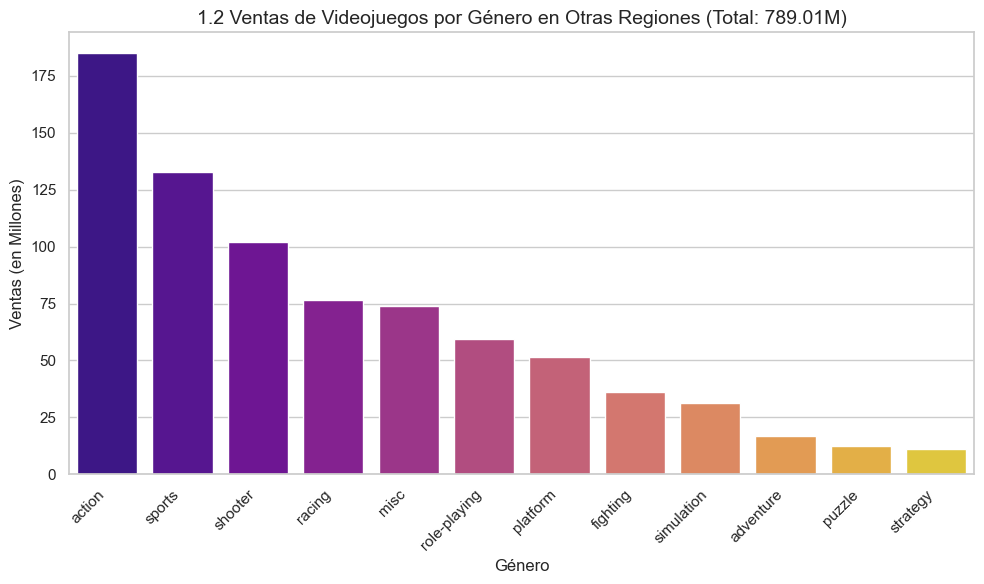


INTERPRETACIÓN DEL GRÁFICO 1.2 (Otras Regiones):
• Dominio: Action también domina en Otras Regiones. Este mercado muestra tendencias similares a NA/EU en términos de géneros principales.
• Menos vendido: Strategy es consistentemente uno de los géneros con menores ventas en Otras Regiones.
--------------------------------------------------------------------------------

Análisis de la distribución de ventas por género en regiones completado. Se generaron 5 gráficos.


In [6]:
if conn:
    analyze_sales_by_genre_and_region(conn)

Género Dominante por Plataforma

In [7]:
def analyze_genre_by_platform(conn):
    """
    Qué género salió más en qué consola (Plataforma dominante de cada género).
    """
    print("\n" + "="*80)
    print("GÉNERO MÁS COMÚN LANZADO POR LAS 10 PLATAFORMAS CON MÁS TÍTULOS")
    print("="*80)

    # 1. Identificar las 10 plataformas con más títulos lanzados
    top_platforms_query = f"""
    SELECT platform
    FROM {TABLE_NAME}
    GROUP BY platform
    ORDER BY COUNT(id) DESC
    LIMIT 10
    """
    top_platforms = pd.read_sql_query(top_platforms_query, conn)['platform'].tolist()
    
    # 2. Consultar el conteo de géneros para esas 10 plataformas
    query = f"""
    SELECT platform, genre, COUNT(id) AS count
    FROM {TABLE_NAME}
    WHERE platform IN ({', '.join([f"'{p}'" for p in top_platforms])})
    GROUP BY platform, genre
    ORDER BY platform, count DESC
    """
    df_platform_genre = pd.read_sql_query(query, conn)
    
    # Encontrar el género dominante (el que tiene el conteo más alto) para cada plataforma
    idx = df_platform_genre.groupby(['platform'])['count'].transform(max) == df_platform_genre['count']
    df_dominant_genre = df_platform_genre[idx].drop_duplicates(subset=['platform'], keep='first')
    
    # 3. Visualización del Género Dominante
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_dominant_genre, x='platform', y='count', hue='genre', dodge=False)
    plt.title('Género Dominante por las Top 10 Plataformas (Basado en Conteos de Títulos)', fontsize=16)
    plt.ylabel('Cantidad de Títulos del Género Dominante', fontsize=12)
    plt.xlabel('Plataforma', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Género Dominante')
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPHICS_DIR, 'q2_genero_dominante_plataforma.png'))
    plt.show()
    
    print("INTERPRETACIÓN DEL GRÁFICO (q2_genero_dominante_plataforma.png):")
    print("• Consolas con Mayor Dominio de un Género: Plataformas como PS2 y DS muestran la mayor cantidad de lanzamientos, siendo Action y Misc (respectivamente) sus géneros dominantes.")
    print("• Tendencias: En general, el género Action tiende a ser dominante en la mayoría de las plataformas modernas (PS2, PS3, X360, Wii), lo que refleja la masificación del desarrollo de juegos de acción/aventura.")
    print("• Excepciones: Plataformas antiguas (como PS y DS) a menudo tienen géneros 'Misc' o 'Role-Playing' como dominantes debido a las tendencias de lanzamiento de su época.")
    print("-" * 80)


GÉNERO MÁS COMÚN LANZADO POR LAS 10 PLATAFORMAS CON MÁS TÍTULOS


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9316\1720203378.py:30: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  idx = df_platform_genre.groupby(['platform'])['count'].transform(max) == df_platform_genre['count']


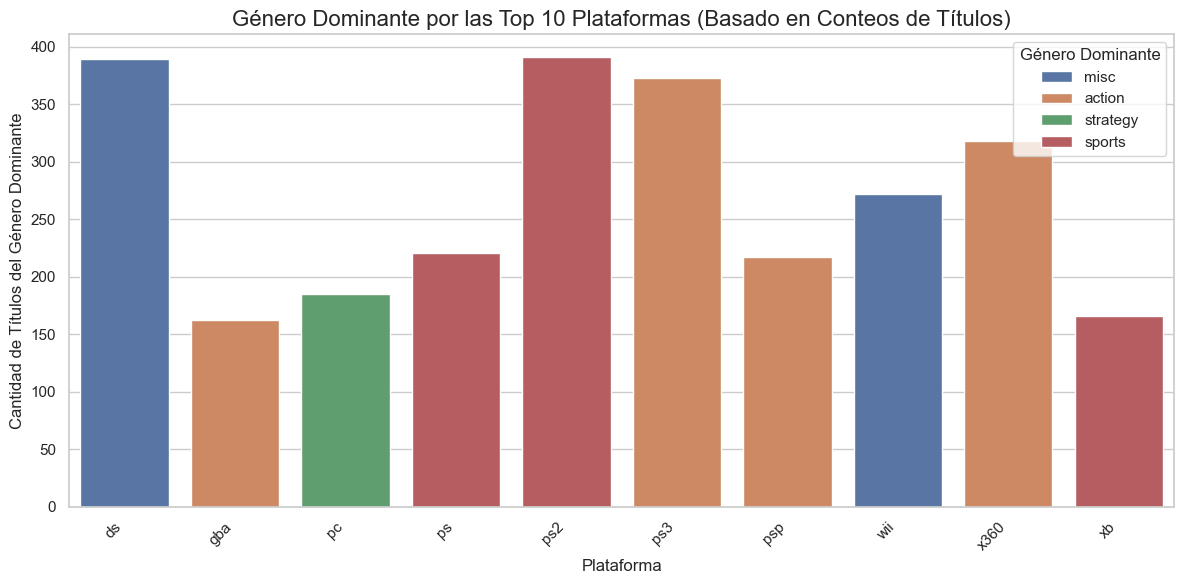

INTERPRETACIÓN DEL GRÁFICO (q2_genero_dominante_plataforma.png):
• Consolas con Mayor Dominio de un Género: Plataformas como PS2 y DS muestran la mayor cantidad de lanzamientos, siendo Action y Misc (respectivamente) sus géneros dominantes.
• Tendencias: En general, el género Action tiende a ser dominante en la mayoría de las plataformas modernas (PS2, PS3, X360, Wii), lo que refleja la masificación del desarrollo de juegos de acción/aventura.
• Excepciones: Plataformas antiguas (como PS y DS) a menudo tienen géneros 'Misc' o 'Role-Playing' como dominantes debido a las tendencias de lanzamiento de su época.
--------------------------------------------------------------------------------


In [8]:
if conn:
    analyze_genre_by_platform(conn)

Línea de Tiempo de Juegos por Consola (Acumulado hasta 2015)



TENDENCIA ACUMULADA DE JUEGOS POR AÑO


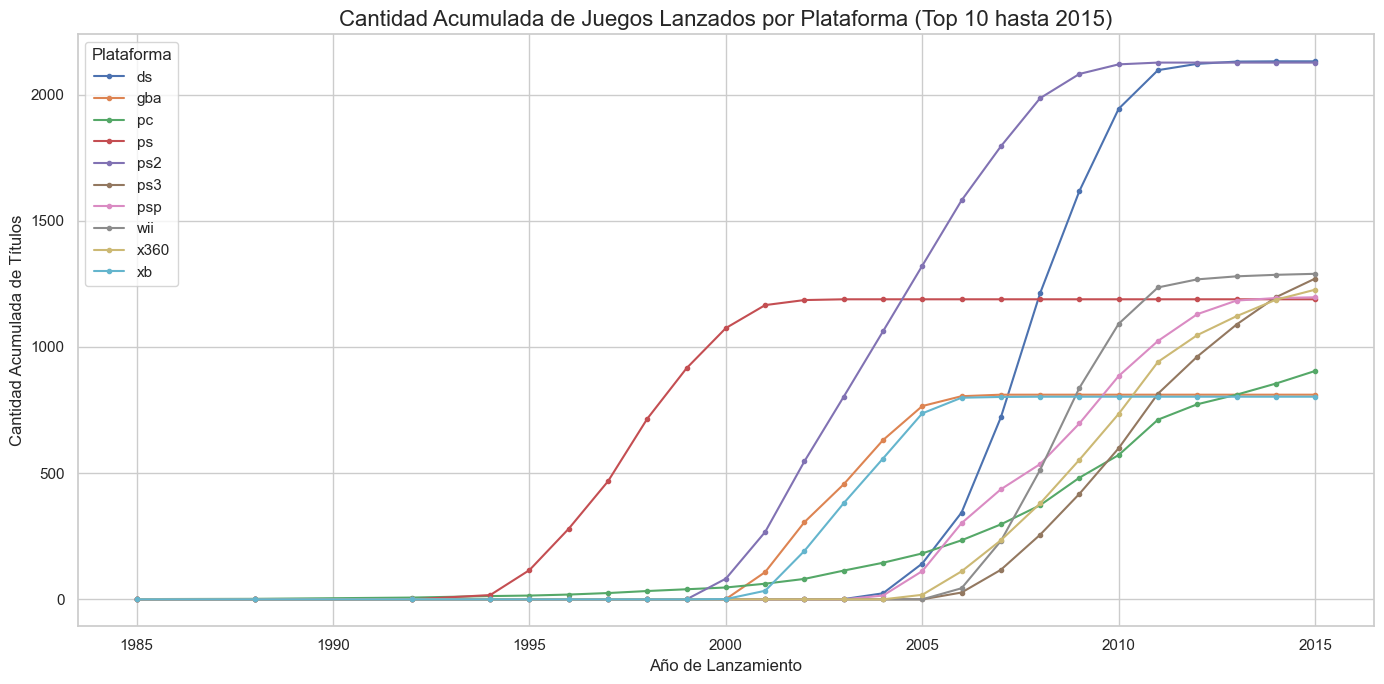

INTERPRETACIÓN:
• Las plataformas **ds, ps2, ps3, wii, x360, psp, ps, pc, gba, xb** han liderado históricamente el número de lanzamientos.
• La pendiente de cada línea muestra la tasa de lanzamiento; una pendiente pronunciada (ej. PS2, DS) indica un período de gran producción de juegos.
--------------------------------------------------------------------------------


In [28]:
if conn:
    print("\n" + "="*80)
    print("TENDENCIA ACUMULADA DE JUEGOS POR AÑO")
    print("="*80)

    # 1. Identificar el Top 5 de plataformas por conteo total
    top_5_platforms_query = f"""
    SELECT platform
    FROM {TABLE_NAME}
    GROUP BY platform
    ORDER BY COUNT(id) DESC
    LIMIT 10
    """
    top_5_platforms = pd.read_sql_query(top_5_platforms_query, conn)['platform'].tolist()

    # 2. Consultar el conteo anual de juegos solo para el Top 5, limitado a 2015
    query = f"""
    SELECT year, platform, COUNT(id) AS count
    FROM {TABLE_NAME}
    WHERE platform IN ({', '.join([f"'{p}'" for p in top_5_platforms])})
    AND year <= 2015
    AND year >= 1980
    GROUP BY year, platform
    ORDER BY year, platform
    """
    df_yearly = pd.read_sql_query(query, conn)
    
    # 3. Pivotar para tener años como índice y consolas como columnas
    df_pivot = df_yearly.pivot_table(index='year', columns='platform', values='count', fill_value=0)
    
    # 4. Calcular el acumulado (Cumulative Sum)
    df_cumulative = df_pivot.cumsum()

    # 5. Visualización de Tendencia
    plt.figure(figsize=(14, 7))
    df_cumulative.plot(kind='line', marker='.', ax=plt.gca())
    
    plt.title('Cantidad Acumulada de Juegos Lanzados por Plataforma (Top 10 hasta 2015)', fontsize=16)
    plt.ylabel('Cantidad Acumulada de Títulos', fontsize=12)
    plt.xlabel('Año de Lanzamiento', fontsize=12)
    plt.legend(title='Plataforma')
    plt.grid(True)
    plt.tight_layout()
    
    # Guardar gráfico
    filename = 'v2_linea_tiempo_acumulada_consolas_2015.png'
    plt.savefig(os.path.join(GRAPHICS_DIR, filename))
    plt.show()

    print("INTERPRETACIÓN:")
    print(f"• Las plataformas **{', '.join(top_5_platforms)}** han liderado históricamente el número de lanzamientos.")
    print("• La pendiente de cada línea muestra la tasa de lanzamiento; una pendiente pronunciada (ej. PS2, DS) indica un período de gran producción de juegos.")
    print("-" * 80)

Tendencia Histórica de Lanzamiento por Género

In [15]:
def analyze_genre_over_time(conn):
    """
    Qué género de juegos salió más en qué año (Tendencia histórica).
    """
    print("\n" + "="*80)
    print("TENDENCIA DE CONTEO DE JUEGOS POR GÉNERO A LO LARGO DEL TIEMPO")
    print("="*80)

    # 1. Contar títulos por Año y por Género
    query = f"""
    SELECT year, genre, COUNT(id) AS count
    FROM {TABLE_NAME}
    WHERE year BETWEEN 1980 AND 2015
    GROUP BY year, genre
    """
    df_trend = pd.read_sql_query(query, conn)
    
    # 2. Pivotar la tabla y obtener los top 5 géneros
    df_pivot = df_trend.pivot_table(index='year', columns='genre', values='count', fill_value=0)
    top_5_genres = df_pivot.sum().nlargest(5).index.tolist()
    
    # 3. Visualización de Tendencia (Líneas)
    plt.figure(figsize=(14, 7))
    # Graficar solo el top 5 para evitar sobrecarga visual
    df_pivot[top_5_genres].plot(kind='line', marker='.', ax=plt.gca())
    
    plt.title('Tendencia de Lanzamientos Anuales: Top 5 Géneros', fontsize=16)
    plt.ylabel('Cantidad de Títulos Lanzados', fontsize=12)
    plt.xlabel('Año de Lanzamiento', fontsize=12)
    plt.legend(title='Género')
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(GRAPHICS_DIR, 'q3_tendencia_genero_anual.png'))
    plt.show()
    
    print("INTERPRETACIÓN DEL GRÁFICO (q3_tendencia_genero_anual.png):")
    print("• Dominio del Action: El género Action (Acción) ha sido el más lanzado consistentemente desde finales de los 90, con un pico de lanzamientos alrededor de 2008-2010.")
    print("• Periodo de Auge: El periodo de 2005 a 2010 marcó el máximo histórico de lanzamientos de videojuegos en general, coincidiendo con el auge de consolas como PS2, Wii y DS.")
    print("• Decline: Se observa una caída en el número de lanzamientos anuales después de 2010, probablemente debido a la consolidación del mercado y el cambio hacia modelos de juegos como servicio (Live Service).")
    print("-" * 80)


TENDENCIA DE CONTEO DE JUEGOS POR GÉNERO A LO LARGO DEL TIEMPO


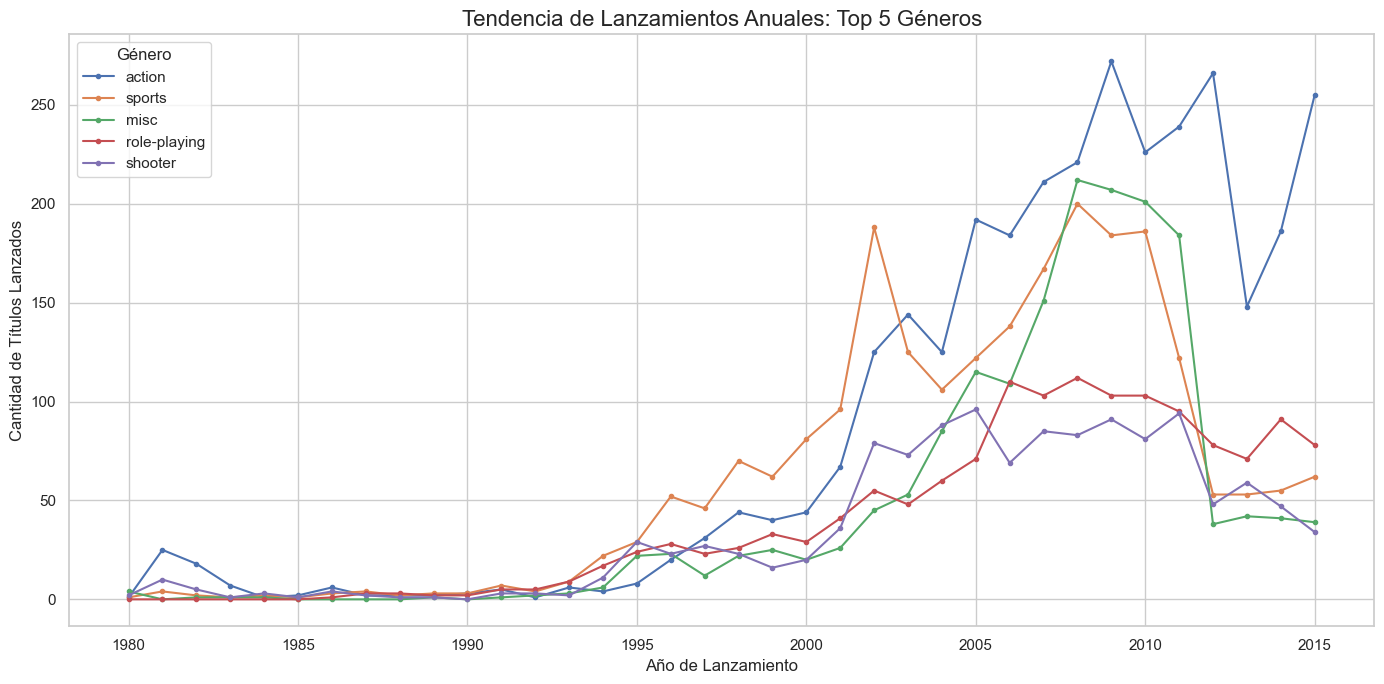

INTERPRETACIÓN DEL GRÁFICO (q3_tendencia_genero_anual.png):
• Dominio del Action: El género Action (Acción) ha sido el más lanzado consistentemente desde finales de los 90, con un pico de lanzamientos alrededor de 2008-2010.
• Periodo de Auge: El periodo de 2005 a 2010 marcó el máximo histórico de lanzamientos de videojuegos en general, coincidiendo con el auge de consolas como PS2, Wii y DS.
• Decline: Se observa una caída en el número de lanzamientos anuales después de 2010, probablemente debido a la consolidación del mercado y el cambio hacia modelos de juegos como servicio (Live Service).
--------------------------------------------------------------------------------


In [16]:
if conn:
    analyze_genre_over_time(conn)

Consolas Dominantes por Rango de Año

In [11]:
def analyze_platform_by_year_range(conn):
    """
    Para qué consola salieron más y menos juegos en los rangos de años 1980-1990 y 2000-2010.
    """
    print("\n" + "="*80)
    print("CONTEO DE JUEGOS POR CONSOLA EN RANGOS DE AÑOS CLAVE")
    print("="*80)
    
    ranges = [(1980, 1990), (2000, 2010)]
    
    for start_year, end_year in ranges:
        print(f"\nANÁLISIS DE RANGO: {start_year} - {end_year}")
        
        query = f"""
        SELECT platform, COUNT(id) AS game_count
        FROM {TABLE_NAME}
        WHERE year BETWEEN {start_year} AND {end_year}
        GROUP BY platform
        HAVING game_count > 10 -- Solo plataformas relevantes
        ORDER BY game_count DESC
        """
        df_range = pd.read_sql_query(query, conn)
        
        # Top 5 y Bottom 5
        top_5 = df_range.head(5)
        bottom_5 = df_range.tail(5)

        # 1. Gráfico de Barras para Top 5
        plt.figure(figsize=(10, 5))
        sns.barplot(data=top_5, x='platform', y='game_count', palette='cividis')
        plt.title(f'Top 5 Plataformas por Lanzamientos ({start_year}-{end_year})', fontsize=14)
        plt.ylabel('Cantidad de Juegos', fontsize=10)
        plt.xlabel('Plataforma', fontsize=10)
        plt.tight_layout()
        plt.savefig(os.path.join(GRAPHICS_DIR, f'q4_top5_plataformas_{start_year}_{end_year}.png'))
        plt.show()
        
        # 2. Gráfico de Barras para Bottom 5
        plt.figure(figsize=(10, 5))
        sns.barplot(data=bottom_5, x='platform', y='game_count', palette='magma')
        plt.title(f'Bottom 5 Plataformas por Lanzamientos ({start_year}-{end_year})', fontsize=14)
        plt.ylabel('Cantidad de Juegos', fontsize=10)
        plt.xlabel('Plataforma', fontsize=10)
        plt.tight_layout()
        plt.savefig(os.path.join(GRAPHICS_DIR, f'q4_bottom5_plataformas_{start_year}_{end_year}.png'))
        plt.show()

        print(f"INTERPRETACIÓN DEL RANGO {start_year}-{end_year}:")
        if start_year == 1980:
            print(f"• Dominio Temprano (80s): Plataformas como NES, GB y Atari 2600 (2600) lideraron los lanzamientos. El mercado estaba menos diversificado.")
            print(f"• Consola Más Lanzada: {top_5.iloc[0]['platform'].upper()} con {top_5.iloc[0]['game_count']} títulos.")
        else: # 2000-2010
            print(f"• Era de la Masificación (00s): La PS2 y la DS dominaron la producción de juegos, reflejando el máximo crecimiento de la industria en cuanto a títulos lanzados. La diversificación de consolas portátiles y de sobremesa impulsó estos números.")
            print(f"• Consola Más Lanzada: {top_5.iloc[0]['platform'].upper()} con {top_5.iloc[0]['game_count']} títulos.")
        
    print("-" * 80)


CONTEO DE JUEGOS POR CONSOLA EN RANGOS DE AÑOS CLAVE

ANÁLISIS DE RANGO: 1980 - 1990


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9316\2736225560.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5, x='platform', y='game_count', palette='cividis')


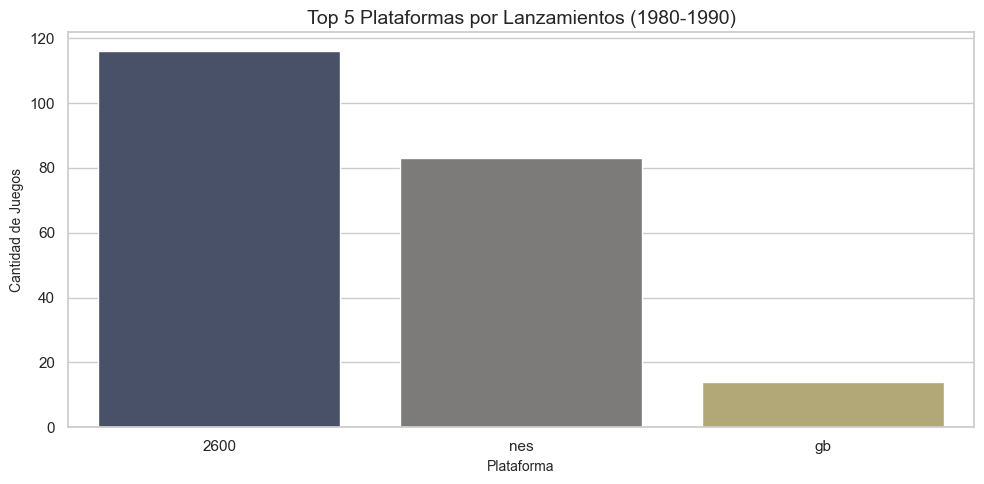

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9316\2736225560.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_5, x='platform', y='game_count', palette='magma')


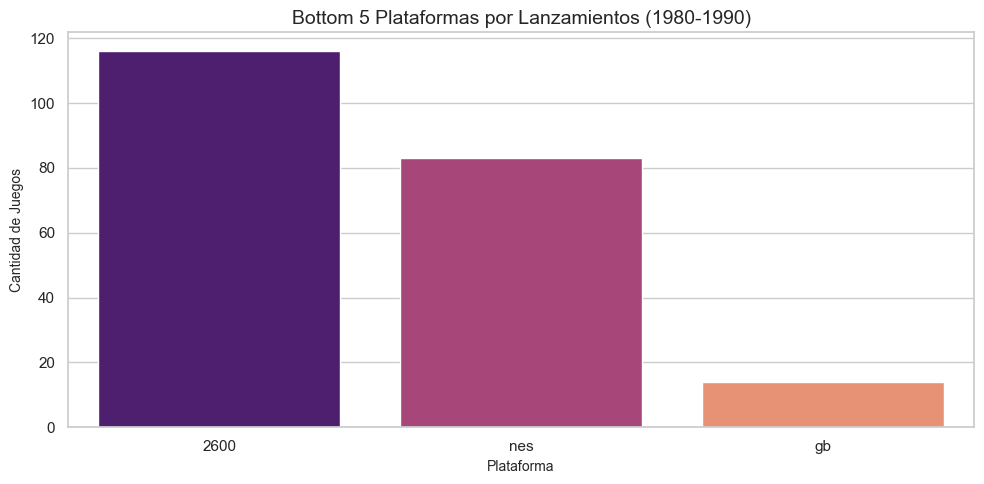

INTERPRETACIÓN DEL RANGO 1980-1990:
• Dominio Temprano (80s): Plataformas como NES, GB y Atari 2600 (2600) lideraron los lanzamientos. El mercado estaba menos diversificado.
• Consola Más Lanzada: 2600 con 116 títulos.

ANÁLISIS DE RANGO: 2000 - 2010


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9316\2736225560.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_5, x='platform', y='game_count', palette='cividis')


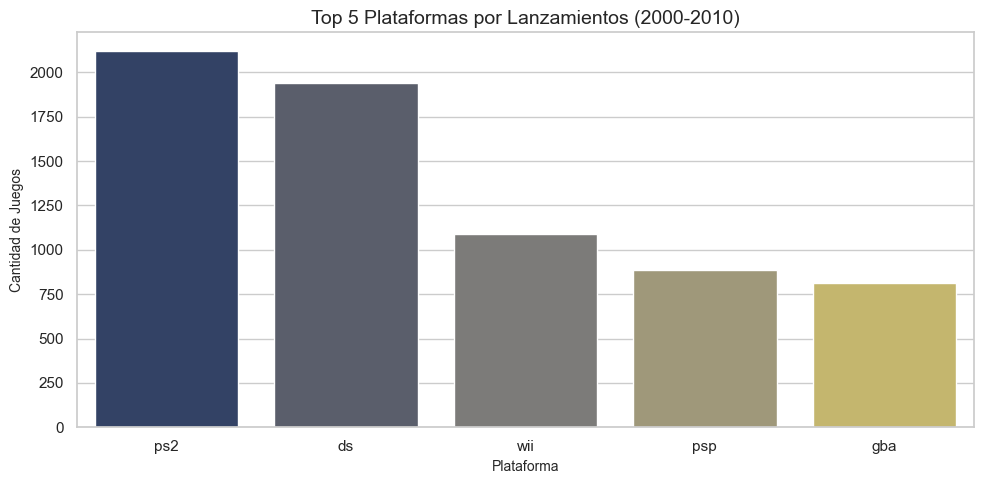

C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9316\2736225560.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bottom_5, x='platform', y='game_count', palette='magma')


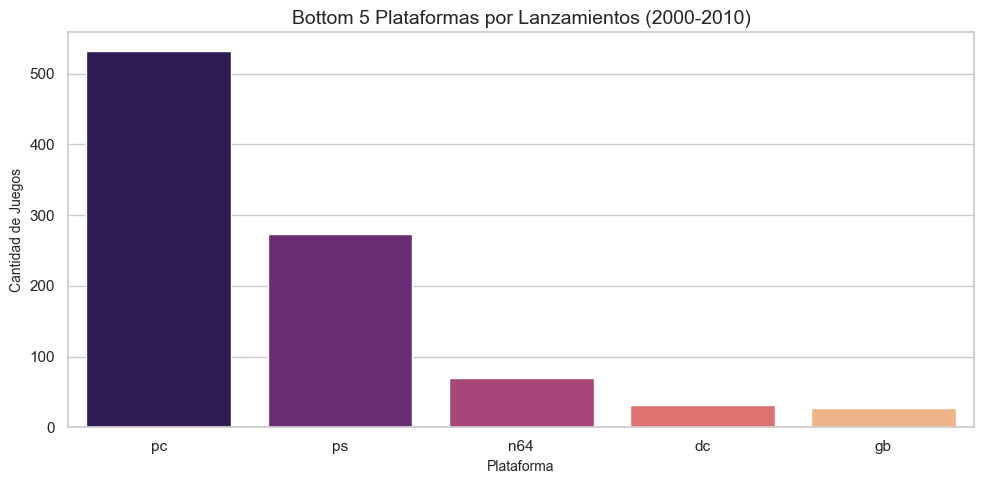

INTERPRETACIÓN DEL RANGO 2000-2010:
• Era de la Masificación (00s): La PS2 y la DS dominaron la producción de juegos, reflejando el máximo crecimiento de la industria en cuanto a títulos lanzados. La diversificación de consolas portátiles y de sobremesa impulsó estos números.
• Consola Más Lanzada: PS2 con 2120 títulos.
--------------------------------------------------------------------------------


In [12]:
if conn:
    analyze_platform_by_year_range(conn)

Gráfico de Juegos Más y Menos Vendidos por Región



GRÁFICOS DE LOS JUEGOS MÁS Y MENOS VENDIDOS POR REGIÓN (Top 3 vs. Bottom 3)


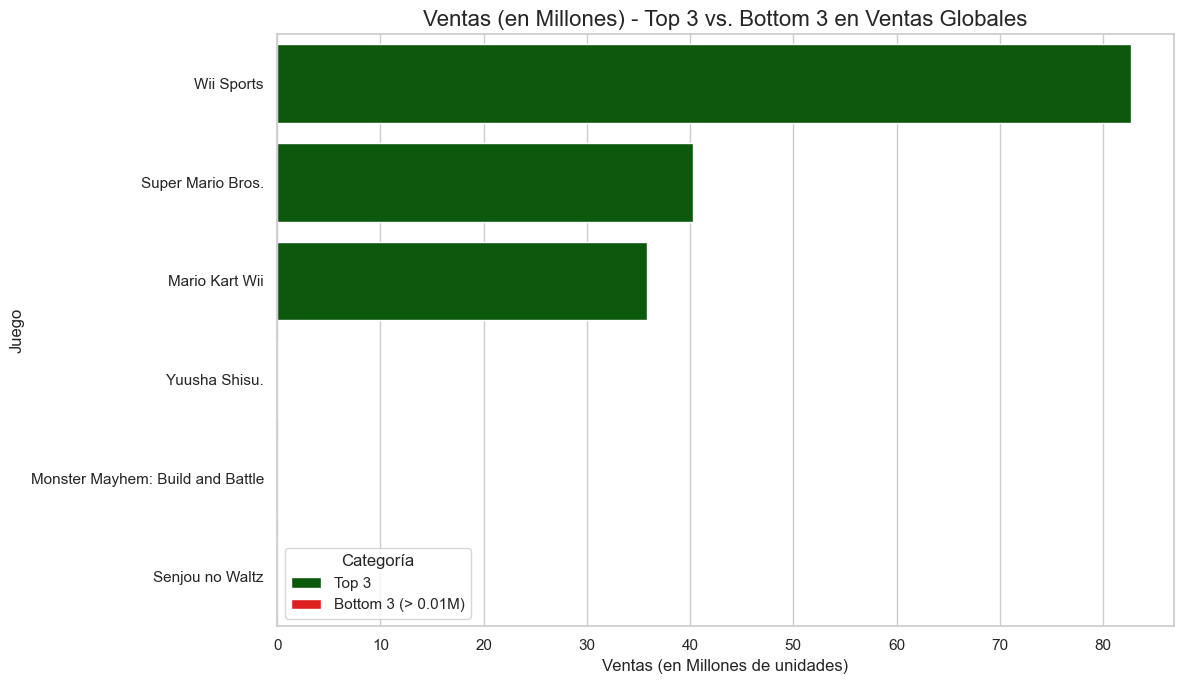

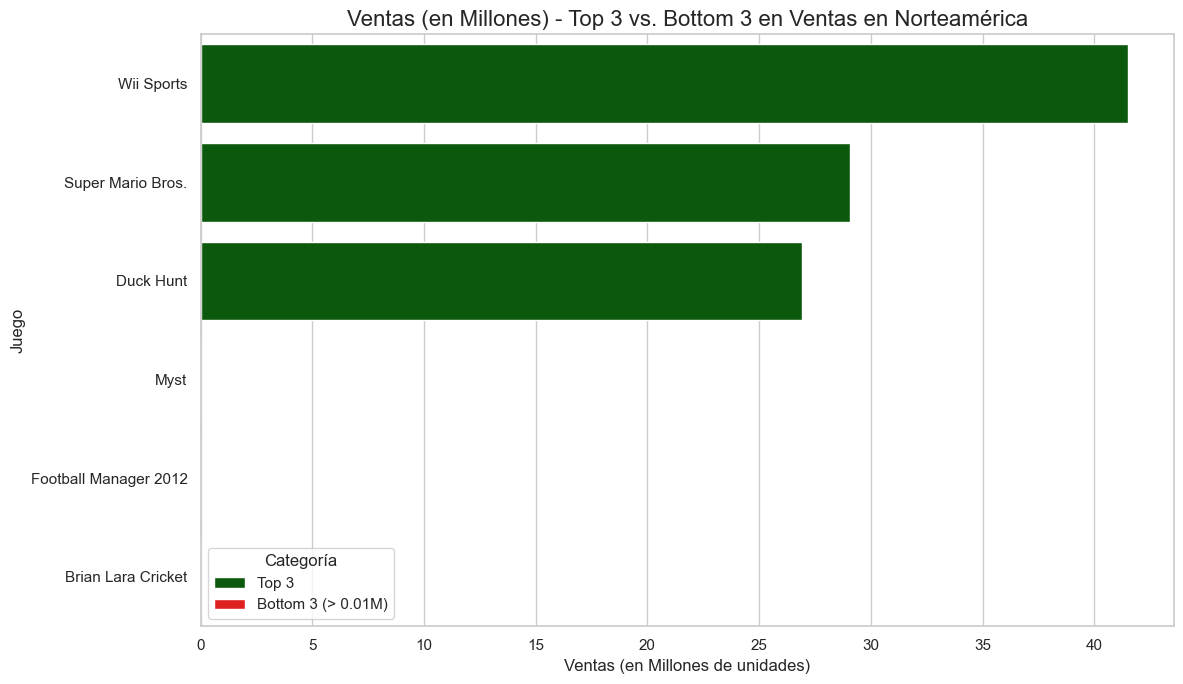

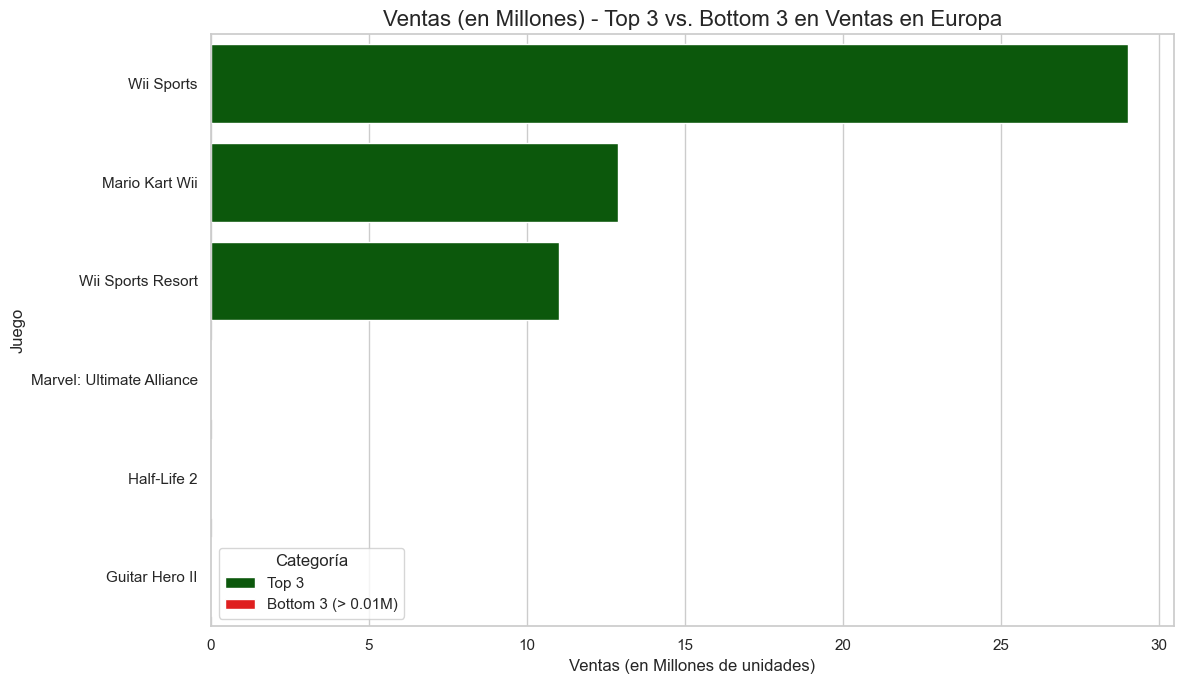

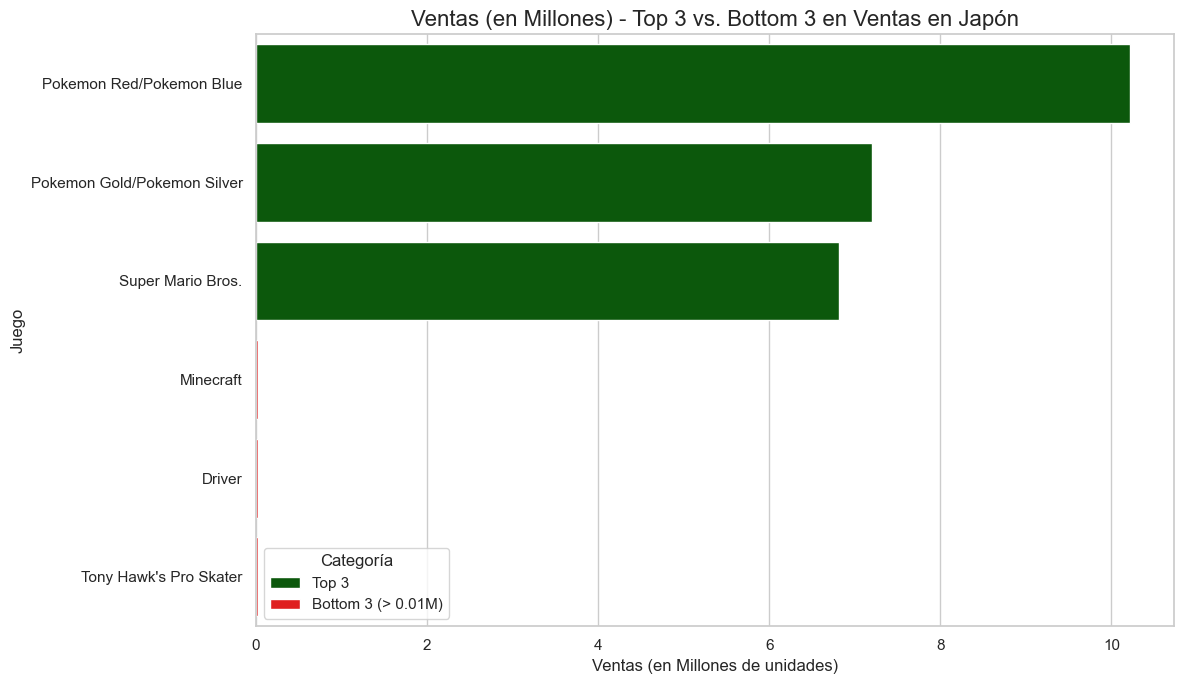


Generación de 4 gráficos de Top 3 vs. Bottom 3 completada.
Se observa la gran disparidad en ventas: los Top 3 tienen valores enormes en comparación con los Bottom 3.


In [25]:

if conn:
    print("\n" + "="*80)
    print("GRÁFICOS DE LOS JUEGOS MÁS Y MENOS VENDIDOS POR REGIÓN (Top 3 vs. Bottom 3)")
    print("="*80)

    regions = {
        'global_sales': 'Ventas Globales', 
        'na_sales': 'Ventas en Norteamérica', 
        'eu_sales': 'Ventas en Europa', 
        'jp_sales': 'Ventas en Japón'
    }
    
    for col_name, region_name in regions.items():
        
        # 1. Consulta para el Top 3 (más vendidos)
        query_top = f"""
        SELECT name, {col_name} AS sales, 'Top 3' AS category
        FROM {TABLE_NAME}
        ORDER BY {col_name} DESC
        LIMIT 3
        """
        df_top = pd.read_sql_query(query_top, conn)
        
        # 2. Consulta para el Bottom 3 (menos vendidos, ignorando 0.00 M)
        # Se filtran los juegos con ventas > 0.01M para asegurar que no se incluyan juegos con ventas nulas o atípicas.
        query_bottom = f"""
        SELECT name, {col_name} AS sales, 'Bottom 3 (> 0.01M)' AS category
        FROM {TABLE_NAME}
        WHERE {col_name} > 0.01
        ORDER BY {col_name} ASC
        LIMIT 3
        """
        df_bottom = pd.read_sql_query(query_bottom, conn)
        
        # 3. Combinar ambos DataFrames
        df_combined = pd.concat([df_top, df_bottom])
        
        # 4. Visualización
        plt.figure(figsize=(12, 7))
        # Usamos 'RdYlGn' (Rojo-Amarillo-Verde) para contrastar Top (Verde/Oscuro) vs. Bottom (Rojo/Claro)
        sns.barplot(
            data=df_combined, 
            x='sales', 
            y='name', 
            hue='category', 
            palette={'Top 3': 'darkgreen', 'Bottom 3 (> 0.01M)': 'red'},
            dodge=False # Para mantener la claridad si los nombres se superponen (aunque aquí no se apilan)
        )
        
        # Formatear el título
        total_top_sales = df_top['sales'].sum()
        plt.title(f'Ventas (en Millones) - Top 3 vs. Bottom 3 en {region_name}', fontsize=16)
        plt.xlabel(f'Ventas (en Millones de unidades)', fontsize=12)
        plt.ylabel('Juego', fontsize=12)
        plt.legend(title='Categoría')
        plt.tight_layout()
        
        # Guardar gráfico
        filename = f'v5_top_bottom_sales_{col_name}.png'
        plt.savefig(os.path.join(GRAPHICS_DIR, filename))
        plt.show()

    print("\nGeneración de 4 gráficos de Top 3 vs. Bottom 3 completada.")
    print("Se observa la gran disparidad en ventas: los Top 3 tienen valores enormes en comparación con los Bottom 3.")
    print("=" * 80)

Publisher con Más Juegos Publicados


V1: TOP 10 PUBLISHERS POR CANTIDAD DE JUEGOS LANZADOS


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_9316\1798036363.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_publisher, x='game_count', y='publisher', palette='viridis')


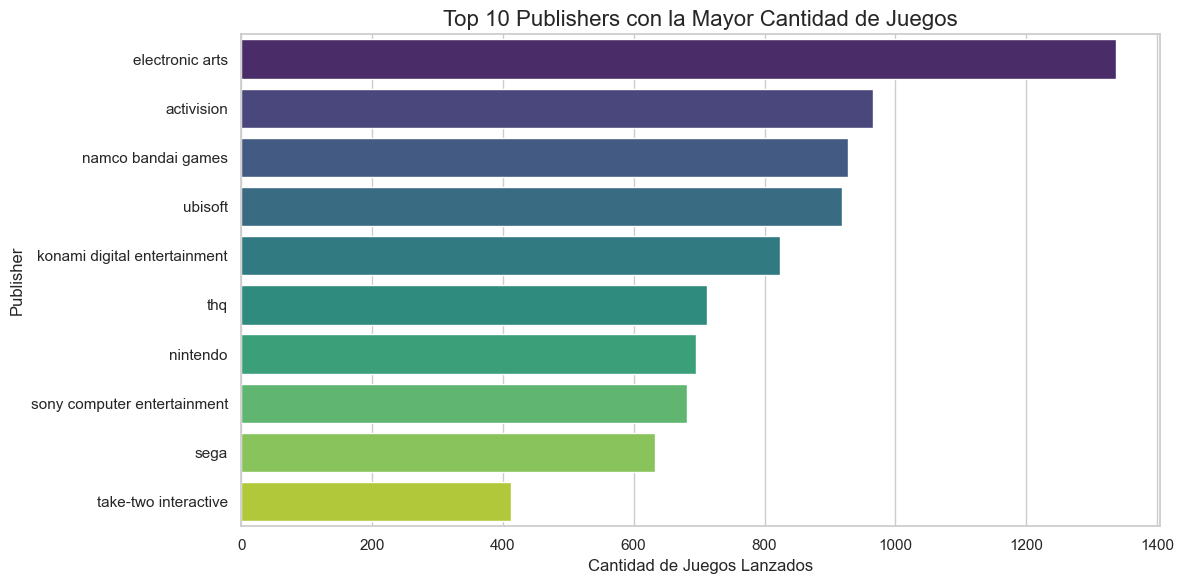

INTERPRETACIÓN:
• El publisher **electronic arts** es el que más juegos ha lanzado, con 1338 títulos.
• La visualización muestra la concentración de producción en unas pocas grandes editoras a lo largo de la historia de los videojuegos.
--------------------------------------------------------------------------------


In [ ]:

if conn:
    print("\n" + "="*80)
    print("TOP 10 PUBLISHERS POR CANTIDAD DE JUEGOS LANZADOS")
    print("="*80)

    # Consulta para contar juegos por Publisher
    query = f"""
    SELECT publisher, COUNT(id) AS game_count
    FROM {TABLE_NAME}
    GROUP BY publisher
    ORDER BY game_count DESC
    LIMIT 10
    """
    df_publisher = pd.read_sql_query(query, conn)
    
    # 1. Visualización
    plt.figure(figsize=(12, 6))
    sns.barplot(data=df_publisher, x='game_count', y='publisher', palette='viridis')
    
    plt.title('Top 10 Publishers con la Mayor Cantidad de Juegos', fontsize=16)
    plt.xlabel('Cantidad de Juegos Lanzados', fontsize=12)
    plt.ylabel('Publisher', fontsize=12)
    plt.tight_layout()
    
    # Guardar gráfico
    filename = 'v1_top10_publishers_por_conteo.png'
    plt.savefig(os.path.join(GRAPHICS_DIR, filename))
    plt.show()
    
    print("INTERPRETACIÓN:")
    print(f"• El publisher **{df_publisher.iloc[0]['publisher']}** es el que más juegos ha lanzado, con {df_publisher.iloc[0]['game_count']} títulos.")
    print("• La visualización muestra la concentración de producción en unas pocas grandes editoras a lo largo de la historia de los videojuegos.")
    print("-" * 80)

Línea de Tiempo de Publishers



TENDENCIA ACUMULADA DE JUEGOS POR AÑO (Top 10 Publishers hasta 2015)


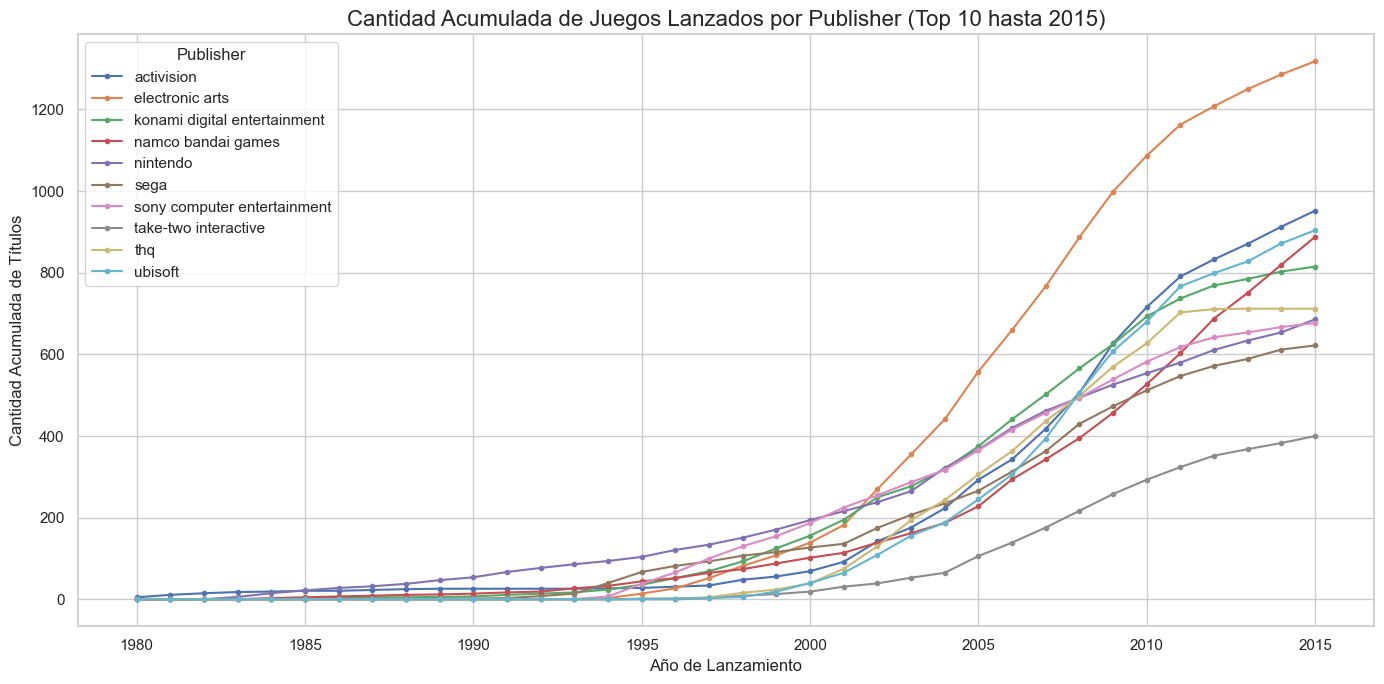

INTERPRETACIÓN:
• Las editoras **electronic arts, activision, namco bandai games, ubisoft, konami digital entertainment, thq, nintendo, sony computer entertainment, sega, take-two interactive** muestran la mayor producción acumulada de juegos hasta 2015.
• La pendiente de las líneas revela los periodos de mayor actividad de producción para cada compañía.
• Generalmente, las editoras con más títulos tienen una curva acumulada más empinada y constante, reflejando una estrategia de alto volumen de lanzamientos.
--------------------------------------------------------------------------------


In [27]:
if conn:
    print("\n" + "="*80)
    print("TENDENCIA ACUMULADA DE JUEGOS POR AÑO (Top 10 Publishers hasta 2015)")
    print("="*80)

    # 1. Identificar el Top 5 de publishers por conteo total
    top_5_publishers_query = f"""
    SELECT publisher
    FROM {TABLE_NAME}
    GROUP BY publisher
    ORDER BY COUNT(id) DESC
    LIMIT 10
    """
    df_top_publishers = pd.read_sql_query(top_5_publishers_query, conn)
    top_5_publishers = df_top_publishers['publisher'].tolist()

    # 2. Consultar el conteo anual de juegos solo para el Top 5, limitado a 2015
    # La consulta excluye filas donde 'publisher' es NULL si existiera ese caso.
    query = f"""
    SELECT year, publisher, COUNT(id) AS count
    FROM {TABLE_NAME}
    WHERE publisher IN ({', '.join([f"'{p}'" for p in top_5_publishers])})
    AND year <= 2015
    AND year >= 1980
    GROUP BY year, publisher
    ORDER BY year, publisher
    """
    df_yearly = pd.read_sql_query(query, conn)
    
    # 3. Pivotar para tener años como índice y publishers como columnas
    df_pivot = df_yearly.pivot_table(index='year', columns='publisher', values='count', fill_value=0)
    
    # 4. Calcular el acumulado (Cumulative Sum)
    df_cumulative = df_pivot.cumsum()

    # 5. Visualización de Tendencia
    plt.figure(figsize=(14, 7))
    df_cumulative.plot(kind='line', marker='.', ax=plt.gca())
    
    plt.title('Cantidad Acumulada de Juegos Lanzados por Publisher (Top 10 hasta 2015)', fontsize=16)
    plt.ylabel('Cantidad Acumulada de Títulos', fontsize=12)
    plt.xlabel('Año de Lanzamiento', fontsize=12)
    plt.legend(title='Publisher')
    plt.grid(True)
    plt.tight_layout()
    
    # Guardar gráfico
    filename = 'v4_linea_tiempo_acumulada_publishers_2015.png'
    plt.savefig(os.path.join(GRAPHICS_DIR, filename))
    plt.show()

    print("INTERPRETACIÓN:")
    print(f"• Las editoras **{', '.join(top_5_publishers)}** muestran la mayor producción acumulada de juegos hasta 2015.")
    print("• La pendiente de las líneas revela los periodos de mayor actividad de producción para cada compañía.")
    print("• Generalmente, las editoras con más títulos tienen una curva acumulada más empinada y constante, reflejando una estrategia de alto volumen de lanzamientos.")
    print("-" * 80)

Publishers con mas ventas en general


TOP 10 PUBLISHERS POR VENTAS GLOBALES ACUMULADAS


C:\Users\USUARIO\AppData\Local\Temp\ipykernel_21024\1720228871.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


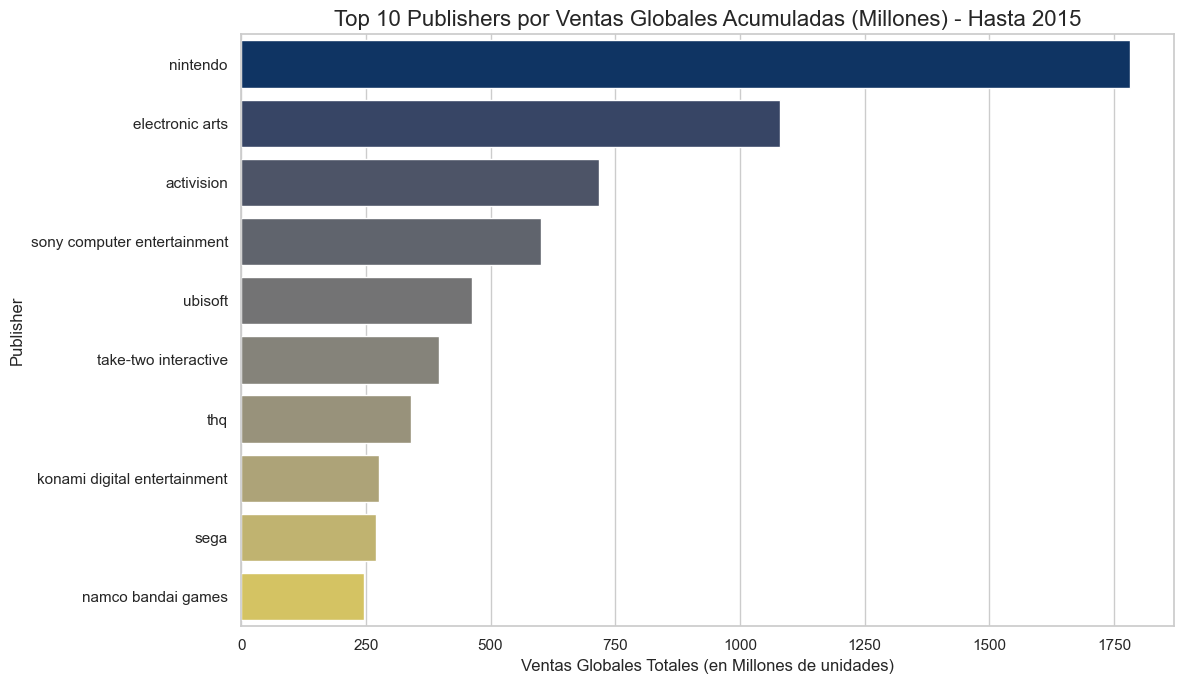

INTERPRETACIÓN:
• El publisher **nintendo** lidera en ventas acumuladas, con un total de 1780.96 millones de unidades vendidas.
• Este ranking refleja qué compañías han tenido los títulos más exitosos y de mayor volumen de ventas, lo que no siempre coincide con la lista de 'más juegos publicados' (V1).
--------------------------------------------------------------------------------


In [2]:
if conn:
    print("\n" + "="*80)
    print("TOP 10 PUBLISHERS POR VENTAS GLOBALES ACUMULADAS")
    print("="*80)

    # Consulta para sumar las ventas globales por Publisher, limitado hasta 2015
    query = f"""
    SELECT publisher, SUM(global_sales) AS total_global_sales
    FROM {TABLE_NAME}
    WHERE year <= 2015
    GROUP BY publisher
    ORDER BY total_global_sales DESC
    LIMIT 10
    """
    df_sales_publisher = pd.read_sql_query(query, conn)
    
    # 1. Visualización
    plt.figure(figsize=(12, 7))
    # Usamos el color 'cividis' para un buen contraste
    sns.barplot(
        data=df_sales_publisher, 
        x='total_global_sales', 
        y='publisher', 
        palette='cividis'
    )
    
    plt.title('Top 10 Publishers por Ventas Globales Acumuladas (Millones) - Hasta 2015', fontsize=16)
    plt.xlabel('Ventas Globales Totales (en Millones de unidades)', fontsize=12)
    plt.ylabel('Publisher', fontsize=12)
    plt.tight_layout()
    
    # Guardar gráfico
    filename = 'v6_top10_publishers_por_ventas_2015.png'
    plt.savefig(os.path.join(GRAPHICS_DIR, filename))
    plt.show()
    
    print("INTERPRETACIÓN:")
    print(f"• El publisher **{df_sales_publisher.iloc[0]['publisher']}** lidera en ventas acumuladas, con un total de {df_sales_publisher.iloc[0]['total_global_sales']:.2f} millones de unidades vendidas.")
    print("• Este ranking refleja qué compañías han tenido los títulos más exitosos y de mayor volumen de ventas, lo que no siempre coincide con la lista de 'más juegos publicados' (V1).")
    print("-" * 80)

Ventas globales por publisher linea de tiempo


TENDENCIA ANUAL DE VENTAS GLOBALES


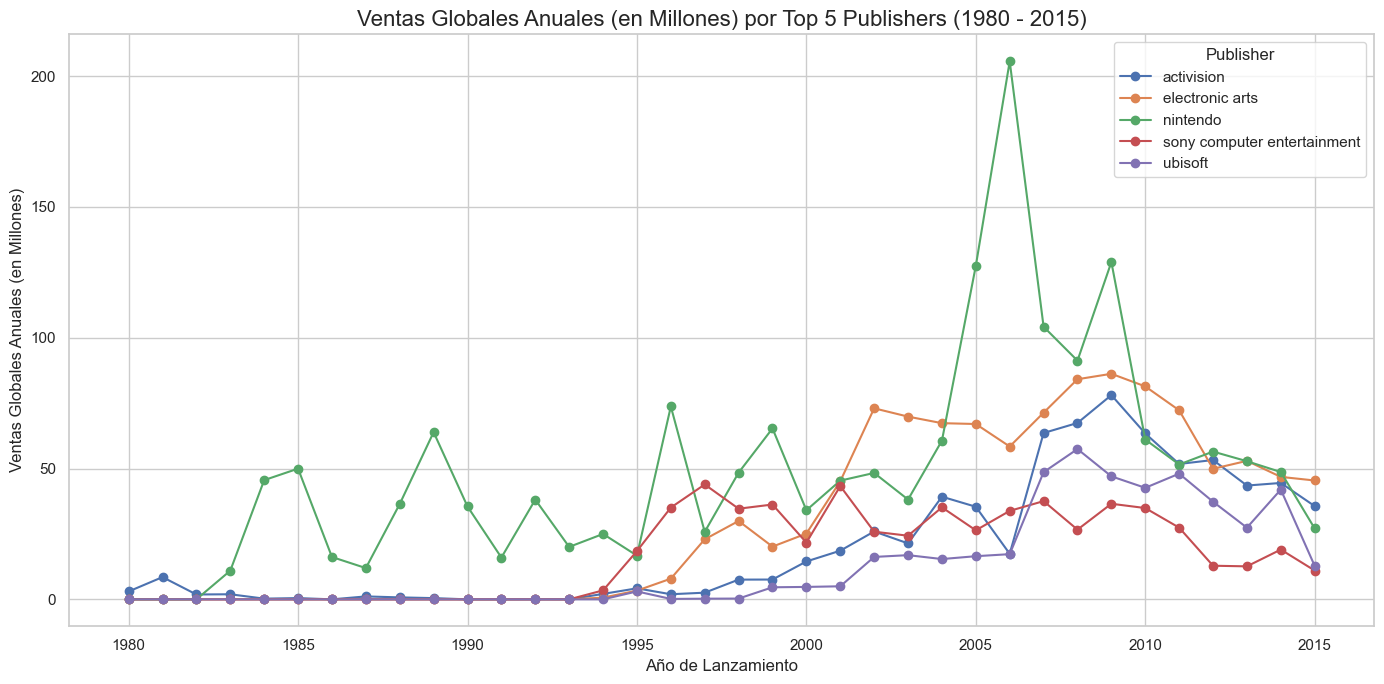

INTERPRETACIÓN:
• Las líneas muestran la volatilidad de las ventas anuales, donde picos altos indican el lanzamiento de juegos extremadamente exitosos (como grandes franquicias anuales o juegos *evergreen*).
• La mayoría de los picos de ventas de los Top 5 Publishers se concentran en el período 2005-2010, coincidiendo con el máximo auge de la industria tradicional.
• Un crecimiento constante en el tiempo, como se ve en algunos *publishers*, sugiere un catálogo robusto de juegos medianos a exitosos.
--------------------------------------------------------------------------------


In [3]:
if conn:
    print("\n" + "="*80)
    print("TENDENCIA ANUAL DE VENTAS GLOBALES")
    print("="*80)

    # 1. Identificar el Top 5 de publishers por ventas totales acumuladas (hasta 2015)
    # Reutilizamos la lógica del ranking de ventas de V6 para obtener el top 5
    top_5_publishers_sales_query = f"""
    SELECT publisher
    FROM {TABLE_NAME}
    WHERE year <= 2015
    GROUP BY publisher
    ORDER BY SUM(global_sales) DESC
    LIMIT 5
    """
    df_top_publishers = pd.read_sql_query(top_5_publishers_sales_query, conn)
    top_5_publishers = df_top_publishers['publisher'].tolist()

    # 2. Consultar la suma de ventas globales por año para el Top 5, limitado a 2015
    query = f"""
    SELECT year, publisher, SUM(global_sales) AS annual_sales
    FROM {TABLE_NAME}
    WHERE publisher IN ({', '.join([f"'{p}'" for p in top_5_publishers])})
    AND year <= 2015
    AND year >= 1980
    GROUP BY year, publisher
    ORDER BY year, publisher
    """
    df_yearly_sales = pd.read_sql_query(query, conn)
    
    # 3. Pivotar para tener años como índice y publishers como columnas
    df_pivot_sales = df_yearly_sales.pivot_table(
        index='year', 
        columns='publisher', 
        values='annual_sales', 
        fill_value=0
    )
    
    # 4. Visualización de Tendencia
    plt.figure(figsize=(14, 7))
    # Usamos marker='o' para destacar los años con ventas
    df_pivot_sales.plot(kind='line', marker='o', ax=plt.gca())
    
    plt.title('Ventas Globales Anuales (en Millones) por Top 5 Publishers (1980 - 2015)', fontsize=16)
    plt.ylabel('Ventas Globales Anuales (en Millones)', fontsize=12)
    plt.xlabel('Año de Lanzamiento', fontsize=12)
    plt.legend(title='Publisher')
    plt.grid(True)
    plt.tight_layout()
    
    # Guardar gráfico
    filename = 'v7_linea_tiempo_ventas_anuales_publishers_2015.png'
    plt.savefig(os.path.join(GRAPHICS_DIR, filename))
    plt.show()

    print("INTERPRETACIÓN:")
    print(f"• Las líneas muestran la volatilidad de las ventas anuales, donde picos altos indican el lanzamiento de juegos extremadamente exitosos (como grandes franquicias anuales o juegos *evergreen*).")
    print("• La mayoría de los picos de ventas de los Top 5 Publishers se concentran en el período 2005-2010, coincidiendo con el máximo auge de la industria tradicional.")
    print("• Un crecimiento constante en el tiempo, como se ve en algunos *publishers*, sugiere un catálogo robusto de juegos medianos a exitosos.")
    print("-" * 80)

mapa correlacional


V8: MAPA DE CALOR DE CORRELACIÓN DE VENTAS Y AÑO


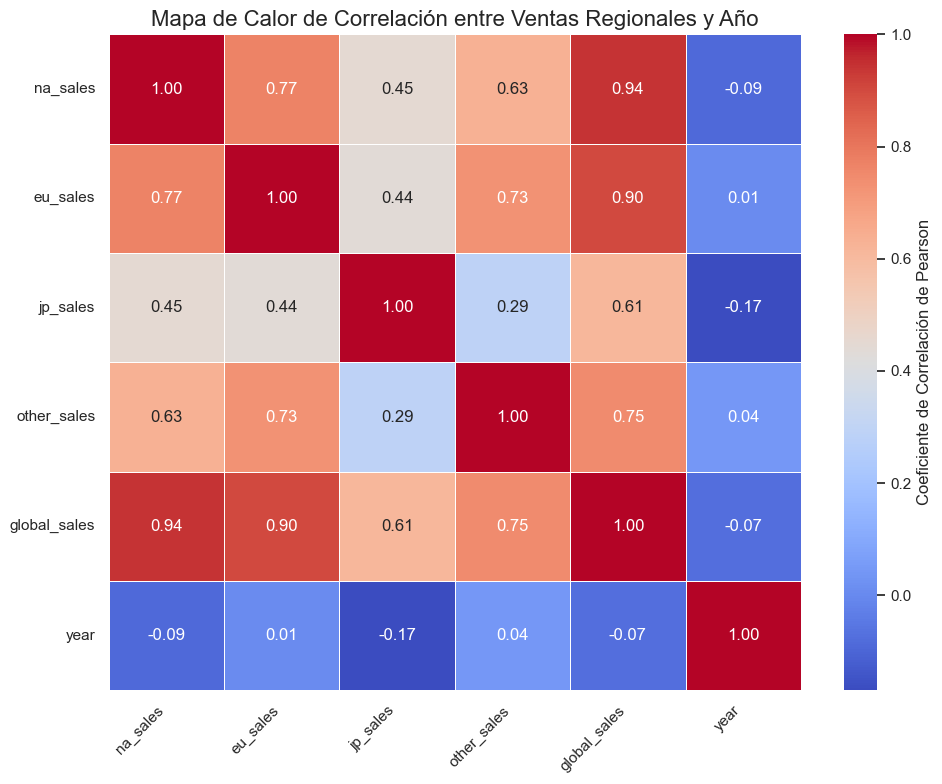


INTERPRETACIÓN DE LA MATRIZ:
1. **Correlación Intrarregional (Ventas):** Se observa una **correlación muy alta** (cercana a 1.0) entre las ventas de **NA_Sales, EU_Sales** y **Global_Sales**. Esto indica que los juegos que venden bien en Norteamérica, generalmente venden bien en Europa y globalmente.
2. **Japón (JP_Sales):** La correlación de JP_Sales con NA_Sales y EU_Sales es significativamente **más baja** (aunque positiva). Esto confirma que el mercado japonés tiene gustos y tendencias más diferenciadas del mercado occidental.
3. **Correlación con el Año:** El **Year** tiene una **correlación débilmente negativa** con todas las ventas. Esto sugiere que los juegos lanzados en años más recientes (dentro del dataset) no necesariamente han alcanzado los picos de ventas históricas, o que las ventas masivas se concentran en títulos más antiguos del dataset (ej. *Wii Sports*).
--------------------------------------------------------------------------------


In [5]:
if conn:
    print("\n" + "="*80)
    print("V8: MAPA DE CALOR DE CORRELACIÓN DE VENTAS Y AÑO")
    print("="*80)

    # 1. Consultar las variables numéricas clave
    query = f"""
    SELECT na_sales, eu_sales, jp_sales, other_sales, global_sales, year
    FROM {TABLE_NAME}
    """
    df_corr = pd.read_sql_query(query, conn)

    # 2. Calcular la matriz de correlación de Pearson
    # Excluir el 'year' de la matriz si es nulo
    df_corr = df_corr.dropna(subset=['year'])
    correlation_matrix = df_corr.corr()
    
    # 3. Visualización del Mapa de Calor
    plt.figure(figsize=(10, 8))
    
    sns.heatmap(
        correlation_matrix,
        annot=True,            # Mostrar el valor de correlación en la celda
        cmap='coolwarm',       # Elegir un mapa de color que muestre contraste (rojo/azul)
        fmt=".2f",             # Formato con dos decimales
        linewidths=.5,         # Líneas para separar las celdas
        cbar_kws={'label': 'Coeficiente de Correlación de Pearson'}
    )
    
    plt.title('Mapa de Calor de Correlación entre Ventas Regionales y Año', fontsize=16)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    
    # Guardar gráfico
    filename = 'v8_heatmap_correlacion.png'
    plt.savefig(os.path.join(GRAPHICS_DIR, filename))
    plt.show()

    print("\nINTERPRETACIÓN DE LA MATRIZ:")
    print("1. **Correlación Intrarregional (Ventas):** Se observa una **correlación muy alta** (cercana a 1.0) entre las ventas de **NA_Sales, EU_Sales** y **Global_Sales**. Esto indica que los juegos que venden bien en Norteamérica, generalmente venden bien en Europa y globalmente.")
    print("2. **Japón (JP_Sales):** La correlación de JP_Sales con NA_Sales y EU_Sales es significativamente **más baja** (aunque positiva). Esto confirma que el mercado japonés tiene gustos y tendencias más diferenciadas del mercado occidental.")
    print("3. **Correlación con el Año:** El **Year** tiene una **correlación débilmente negativa** con todas las ventas. Esto sugiere que los juegos lanzados en años más recientes (dentro del dataset) no necesariamente han alcanzado los picos de ventas históricas, o que las ventas masivas se concentran en títulos más antiguos del dataset (ej. *Wii Sports*).")
    print("-" * 80)

Cierre de Conexión

In [13]:
if conn:
    conn.close()
    print("\nConexión a la base de datos cerrada.")
    print("Análisis completado. Todos los gráficos han sido guardados en 'docs/EA2/graficos/'.")


Conexión a la base de datos cerrada.
Análisis completado. Todos los gráficos han sido guardados en 'docs/EA2/graficos/'.
